## Import Libraries and Initial Configuration

In [1]:
#!pip -q install nltk hnswlib sentencepiece wordninja sentence_transformers

In [2]:
#!pip -q install --upgrade ipywidgets datasets

In [3]:
!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

In [4]:
import os

from datasets import load_dataset, Dataset, DatasetDict

import numpy as np

from sentence_transformers import SentenceTransformer, CrossEncoder
import pickle

import hnswlib

import torch
from transformers import T5Tokenizer, T5ForConditionalGeneration, AutoTokenizer, AutoModelForCausalLM, EarlyStoppingCallback

import pandas as pd
import matplotlib.pyplot as plt

import re

from collections import Counter

import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk import pos_tag

from scipy.stats import pearsonr

from mpl_toolkits.mplot3d import Axes3D

import seaborn as sns

import random

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

import plotly.graph_objects as go
import plotly.express as px

import wordninja

In [5]:
# Optional Code for Google Colab

''' 
from google.colab import output
from google.colab import drive

output.enable_custom_widget_manager()

drive.mount('/content/drive')

path = 'Colab Notebooks/NLP - Project'

os.chdir(f'/content/drive/MyDrive/{path}')
os.getcwd()
'''

" \nfrom google.colab import output\nfrom google.colab import drive\n\noutput.enable_custom_widget_manager()\n\ndrive.mount('/content/drive')\n\npath = 'Colab Notebooks/NLP - Project'\n\nos.chdir(f'/content/drive/MyDrive/{path}')\nos.getcwd()\n"

# Data Preparation

## Dataset Import

In [6]:
# Load the RACE dataset, specifying the desired configuration

dataset_complete = load_dataset("ehovy/race", "all")
dataset_high = load_dataset("ehovy/race", "high")
dataset_middle = load_dataset("ehovy/race", "middle")

## Dataset Manipulation

**Observation**: The original dataset contained many duplicated articles, with each question linked to its corresponding article in the table. To improve efficiency, we decided to compress the dataset by keeping each article only once and nesting all related questions within it.

This version is more direct and easier to understand while preserving the original meaning.

First i will recostruct the data using multiple dictionaries containing each an id of the article as key and inside it the text of the article with in it also the text of the article and the list of questions and answers.

In [7]:
def create_article_mapping(dataset_complete):
    """Create a consistent article to ID mapping for the complete dataset"""
    article_to_id = {}
    for split in ['train', 'validation', 'test']:
      for example in dataset_complete[split]:
          article = example['article']
          if article not in article_to_id:
              article_to_id[article] = len(article_to_id)
    return article_to_id

In [8]:
def restructure_dataset_with_mapping(dataset, article_to_id):
    """
    Restructures dataset using pre-defined article IDs
    Returns dictionary with article_id as keys
    """
    restructured = {}

    for example in dataset:
        article = example['article']
        article_id = article_to_id[article]

        question_info = {
            'example_id': example['example_id'],
            'question': example['question'],
            'options': example['options'],
            'answer': example['answer']
        }

        if article_id not in restructured:
            restructured[article_id] = {
                'article_text': article,
                'questions': []
            }

        restructured[article_id]['questions'].append(question_info)

    return restructured

In [9]:
# First create the unified mapping using the complete dataset
article_to_id = create_article_mapping(dataset_complete)

# Then restructure all datasets using the same mapping
middle_train_dict = restructure_dataset_with_mapping(dataset_middle['train'], article_to_id)
high_train_dict = restructure_dataset_with_mapping(dataset_high['train'], article_to_id)
complete_train_dict = restructure_dataset_with_mapping(dataset_complete['train'], article_to_id)

middle_validation_dict = restructure_dataset_with_mapping(dataset_middle['validation'], article_to_id)
high_validation_dict = restructure_dataset_with_mapping(dataset_high['validation'], article_to_id)
complete_validation_dict = restructure_dataset_with_mapping(dataset_complete['validation'], article_to_id)


middle_test_dict = restructure_dataset_with_mapping(dataset_middle['test'], article_to_id)
high_test_dict = restructure_dataset_with_mapping(dataset_high['test'], article_to_id)
complete_test_dict = restructure_dataset_with_mapping(dataset_complete['test'], article_to_id)

In [10]:
dataset_dict = {  # Initialize as a dictionary
    'middle': {
        'train': middle_train_dict,
        'validation': middle_validation_dict,
        'test': middle_test_dict
    },
    'high': {
        'train': high_train_dict,
        'validation': high_validation_dict,
        'test': high_test_dict
    },
    'all': {
        'train': complete_train_dict,
        'validation': complete_validation_dict,
        'test': complete_test_dict
    }
}

In [11]:
dataset_dict['all']['train'][998]

{'article_text': 'LONDON, Aug. 19 (Xinhua) -- A four-year-old child\'s ability to draw could be an indicator of intelligence at age 14, according to a study published on Tuesday in the British journal Psychological Science.\nThe researchers from King\'s College London (KCL) studied 7,752 pairs of identical and non-identical twins, and found that the link between drawing and later intelligence was influenced by genes.\nAt the age of 4, children were asked by their parents to complete a \'Draw-a-Child\' test. Their drawings were rated from 0 to 12, based on the presence and correct number of body-parts, like arms, legs, head, eyes and nose.\nThe children were also given verbal and non-verbal intelligence tests at ages 4 and 14. According to researchers, the test was devised in the 1920\'s to assess children\'s intelligence, so it\'s not surprising that the test correlated with intelligence at age 4.However, they found that higher scores on the test were also moderately associated with hi

## Splitninja

Quick note: this dataset is bad. It has several bad formatting. The first time I tried to produce this 3d plot I immediately realized there were some incogruencies.

Article 21118 has no spaces between words

In [12]:
middle_train_dict[21118]

{'article_text': 'Somepeoplethinkthatsingingcanliftourspirits ,whilesomeotherpeople  don\'tthinkso.Theydon\'tlikesingingandtheythinksingingcannevermakethemhappy.Ido thinksingingcanmakeusfeelgood,anditcanliftourspirits.Letmetellyoumoreaboutthat.\nSomeresearchers oncedidsomesurveysandprovedit.Thesurveysshow  thatsingingcanbringalotofhealthbenefits .Ifyousingwithyourfriends,theeffectsmay be evenbetter.\nJohnLennonwasonceateacherofVocalPerformance atEmporiaState University.Hesays,"Singingisaninborn need.Babiessingtothemselvesandthey seemsohappy.Likebabies,whenwesing,wefeelsogoodandsingingmakesusfeelevenbetter.I likesingingandIamhappyeveryday."\nMusicisapartofhumannature.Andsingingisaformof _ thatcanbeunderstoodby everyone.Somepeoplesaythatmusicislikeakindoflanguage.Thelanguagecanshow people\'sopinionsandattitudes totheirlife.Somesongscancheerpeopleupwhentheyarein trouble.Somesongscanmakepeoplehappyandexcited.That\'swhytheTVshowTheVoiceof Chinaissopopularwithpeople.',
 'questions': [{'examp

In [13]:
high_train_dict[11910]

{'article_text': 'TheUnitedStateshasaround475,000schoolbuses.Eachdaytheycarrymorethan25million children,halfofalltheschoolchildreninthecountry.\nThesebuses,onaverage,use4litersofdiesel fueltotravellessthan16kilometers. When theschoolyearbeganlastfall,dieselaveraged55centsaliternationally.Thepricenearlydoubledby theendofschool inJune.\nBobRileyisthespokesmanfortheAmericanSchoolBusCouncil.Hesaysfuelpricesnegotiated  for schools arenot lower thanothers have to pay. Asaresult,schoolsarelookingfor waystoreducetransportationcosts.Busroutesarebeing redrawnor,insomecases,canceled.Someareas arebuyingbusesthatuse naturalgas orother alternativefuels.\nOtherstepsincludefewerfieldtrips andlesstravel bysports teams.Someschool districtsmayend any busservicenotrequiredby law.\nStudiesshowthatschoolbusesarethesafestform oftransportationtoandfrom school.\nThe AmericanSchoolBus Councilsayscutsinbus serviceare badfor childrenandpossiblythe environment.Itsaysremovingbusesfromtheroadwillmeananincreaseinothe

proof that it was not our fault:
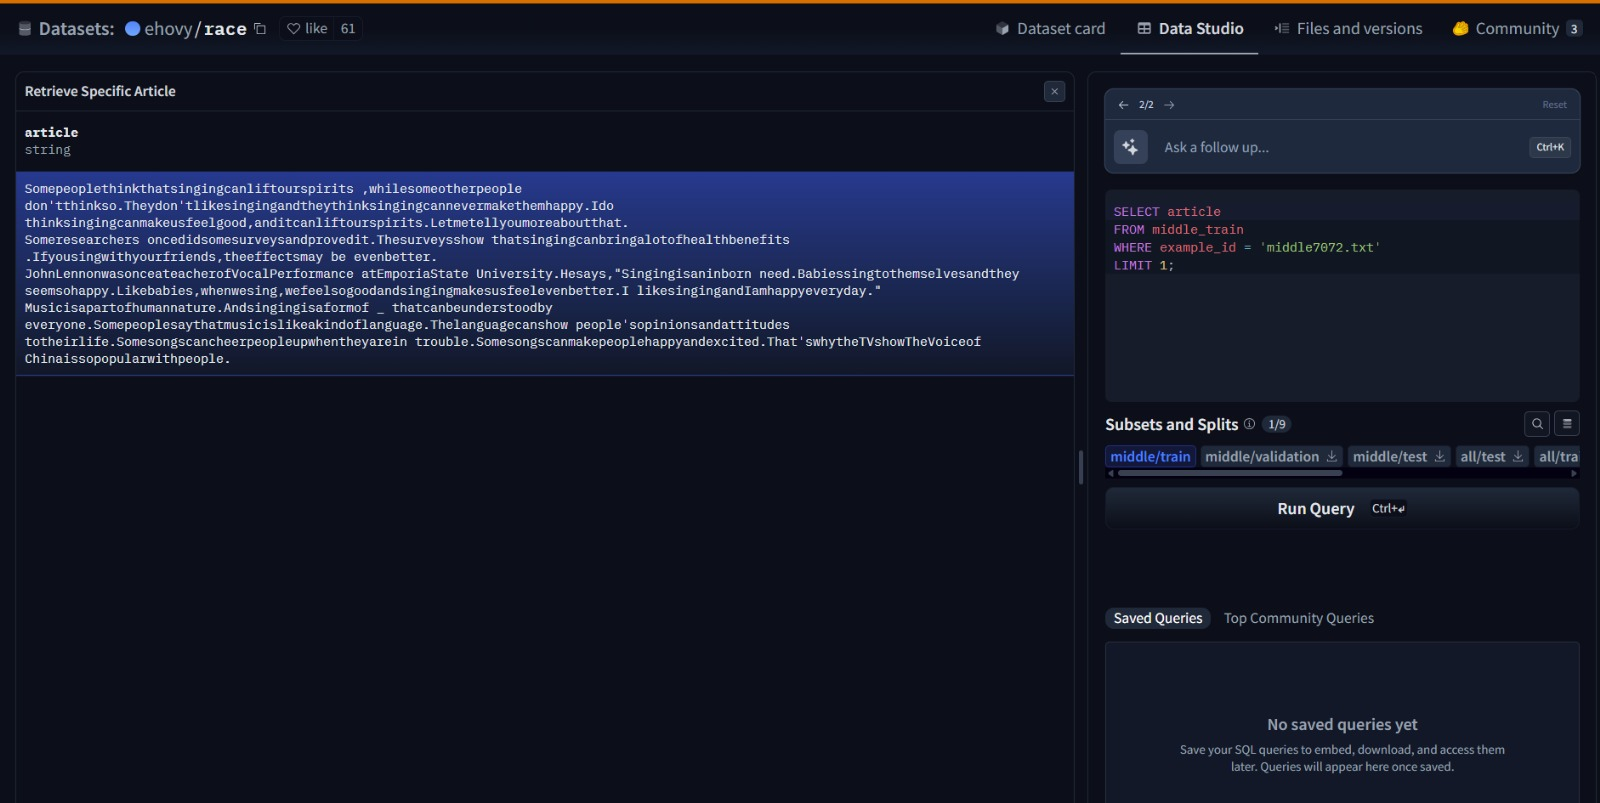

**Approach to Handling Merged Words**
To address this issue, we used the SplitNinja library, but only in cases where we detected unusually long words (those exceeding 15 characters). We avoided applying SplitNinja to the entire dataset for two key reasons:



1.   **Computational Efficiency:** Processing every document would have been unnecessarily resource-intensive.
2.   **Risk of Over-Splitting:** Since most articles were already correctly split, running SplitNinja universally could have introduced errors. The library works by first merging all words and then re-splitting them statistically, which might disrupt properly formatted text.


**Conclusion**
We opted for a conservative approach, applying SplitNinja only when we had strong evidence of merged words (e.g., extreme word length). While this strategy may have missed some edge cases or left minor errors uncorrected, it prioritized precision over coverage—a tradeoff we deemed necessary to maintain data integrity.



There is one last problem we had to face. Splitninja removed punctuation so we need a wrapper function to keep it:

In [14]:
def smart_split(text, min_word_length=15):
    # 1) Normalize line breaks
    text = text.replace('.\n', ' . ')
    text = text.replace('\n', ' . ')

    # 2) Ensure long words ending with punctuation get separated from the next capitalized word
    #    (using only . ? ! for example; extend the class as you like)
    text = re.sub(r'(\b\w{3,})([.!?])\s*(\b[A-Z]\w{2,})',
                  r'\1 \2 \3',
                  text)

    # 3) Tokenize into “words” vs everything else
    tokens = re.findall(r'([A-Za-z]+|[^A-Za-z])', text)

    # 4) Rebuild with spaces after every token
    processed = []
    for token in tokens:
        if token.isalpha():
            # split long “words” into subwords
            processed.extend(wordninja.split(token))
        else:
            if(token!= ' '):
              processed.append(token)

    text = " ".join(processed)

    # 5) Clean up spaces before punctuation (e.g. remove the space before . ? ! , etc.)
    text = re.sub(r'(\w)\s+([.?!,;:—…])', r'\1\2', text)

    return text

Test to see if the word tokenizer works as expected:

In [15]:
# Test
text = "Hello.World\nThisIsATest. Hello"
processed = smart_split(text)
processed

'Hello. World. This Is A Test. Hello'

unfortunately it has some problem when it comes to apostrophes but covering all case would cost me too much time.

In [16]:
# Test
text = "I'm the best programmer cause I'\m the best"
processed = smart_split(text)
processed

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_6421/772063760.py:2: SyntaxWarning: invalid escape sequence '\m'
  text = "I'm the best programmer cause I'\m the best"


"I ' m the best programmer cause I ' \\ m the best"

In [17]:
def apply_wordninja_splitting(restructured_data, char_threshold=20):
    """
    Applies wordninja splitting ONLY to documents containing at least one
    word with more than `char_threshold` characters.
    """
    subsets = ['high', 'middle', 'all']
    splits = ['train', 'validation', 'test']

    for subset in subsets:
        for split in splits:
            data_for_subset = restructured_data[subset][split]
            for article_id in data_for_subset:
                original_text = data_for_subset[article_id]['article_text']

                # Check if document contains any long words
                has_long_word = any(
                    len(word) > char_threshold
                    for word in original_text.split()  # Simple space-based tokenization
                )

                # Apply wordninja only if long words detected
                if has_long_word:
                    #print(subset + ' ' + split + ' ' + str(article_id))
                    processed_text = smart_split(original_text)
                    data_for_subset[article_id]['article_text'] = processed_text

    return restructured_data

dataset_dict=apply_wordninja_splitting(dataset_dict)

Now if we check though for the previously critical datasets that had a lot of words unified it seems that they are not unified anymore

In [18]:
middle_train_dict[21118]

{'article_text': 'Some people think that singing can lift our spirits, while some other people don \' t think so. They don \' t like singing and they think singing can never make them happy. Ido think singing can make us feelgood, and it can lift our spirits. Let me tell you more about that. Some researchers once did some surveys and proved it. The surveys show that singing can bring a lot of health benefits. If you sing with your friends, the effects may be even better. John Lennon was once a teacher of Vocal Performance at Emporia State University. He says, " Singing is an in born need. Babies sing to themselves and they seem so happy. Like babies, when we sing, we feel so good and singing makes us feel even better. I like singing and Iam happy everyday. " . Music is apart of human nature. And singing is a form of _ that can be understood by everyone. Some people say that music is like a kind of language. The language can show people \' s opinions and attitudes to their life. Some so

In [19]:
high_train_dict[11910]

{'article_text': 'The United States has around 4 7 5, 0 0 0 school buses. Each day they carry more than 2 5 million children, half of all the schoolchildren in the country. These buses, on average, use 4 liters of diesel fuel to travel less than 1 6 kilometers. When the school year began last fall, diesel averaged 5 5 cents a liter nationally. The price nearly doubled by the end of school in June. Bob Riley is the spokesman for the American School Bus Council. He says fuel prices negotiated for schools are not lower than others have to pay. As a result, schools are looking for ways to reduce transportation costs. Bus routes are being redrawn or, in some cases, canceled. Some areas are buying buses that use natural gas or other alternative fuels. Other steps include fewer field trips and less travel by sports teams. Some school districts may end any bus service not required by law. Studies show that school buses are the safest form of transportation to and from school. The American Scho

This has a price though: normally long words like websites were divided. Moreover word Ninja computes decently fast but sometimes makes some small error so this is something to be noted.

# T5 FLAN for Zero, One and Few-shot learning

## Libraries Required

In [ ]:
from transformers import  T5Tokenizer, T5ForConditionalGeneration, pipeline, set_seed
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import os
from datasets import load_dataset, Dataset, DatasetDict
import numpy as np

In [ ]:
set_seed(42)

## Introduction of the Experiment

In this experiment a T5 FLAN Model will be used to tackle the **Q&A task** by using a pretrained model with no fine-tuning.

To simplify the usage of the model, a Pipeline object will be used to compute the predictions.

In [82]:
model_name = "google/flan-t5-large"
model = T5ForConditionalGeneration.from_pretrained(model_name, torch_dtype=torch.bfloat16)
tokenizer = T5Tokenizer.from_pretrained(model_name)
generator = pipeline("text2text-generation", model=model, tokenizer=tokenizer)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Device set to use cuda:0


This set of helper functions will be used for the following cells of code, a brief description of all of them is provided below:

`build_promts`: It takes the dataset and constructs a new one extracting the requested split ('train', 'test', 'val') and subset ('all', 'middle', 'high'). Additionally, the prompting strategy can be defined to include examples of questions and answers.

It return a single Dataset object with the following structure:

```
{
  "promt" : <promts containing the context, question, options and the request for the answer>,
  "answer" : <letter corresponding to the correct answer>
}
```

`format_question`: It receives a question dict and return a string with the question for the prompt, optionally including the answer.

`get_random_questions`: This function is used to build the **test cases** for all the tree scenarios: zero, one and few shot learning. This function returns a set of one or four questions (depending on the prompt type) to be added as examples on the main prompt. If possible, other questions relating to the passage will be used, if needed a set of default question will be used to return the requested amount of questions.

In [83]:
def build_prompts(dataset_dict, subset='all', split='train', prompt_type="zero"):
    data = dataset_dict[subset][split]

    prompts = []
    answers = []

    for article_id, article_entry in data.items():
        context = article_entry['article_text']
        for q in article_entry['questions']:
            instruction_header = "Given the following context and question with options, select the letter (A, B, C or D) that correspond to the correct answer:"
            context_block = f"<Context> {context}"
            tail_block = format_question(q, include_answer=False)
            
            # Build prompt based on the type
            if prompt_type == "zero":
                prompt = f"{instruction_header}\n{context_block}\n{tail_block}"
            elif prompt_type == "one":        
                example_prompt = format_question(get_random_questions(article_entry['questions'], q)[0])
                prompt = f"{instruction_header}\n{context_block}\n{example_prompt}\n{tail_block}"
            elif prompt_type == "few":
                few_shot_examples = get_random_questions(article_entry['questions'], q, prompt_type=prompt_type)
                few_shot_examples_block = "".join([format_question(example) for example in few_shot_examples])
                prompt = f"{instruction_header}\n{context_block}\n{few_shot_examples_block}{tail_block}"
                
            prompts.append(prompt)
            answers.append(q['answer'])

    processed_data = Dataset.from_dict({
        "prompt": prompts,
        "answer" : answers
    })

    return processed_data
    
def format_question(q, include_answer=True):
    question = q['question']
    options = q['options']
    answer_letter = q['answer']

    options_block = "\n".join([f"{chr(65+i)}) {opt}" for i, opt in enumerate(options)])

    return f"<Question> {question}\n\n{options_block}\n(Select: A, B, C, or D) <Answer>: {answer_letter if include_answer else ""}\n"

def get_random_questions(question_set, base_question, prompt_type="one"):

    default_question_set = [
        {
            "question": "According to the report, _ .",
            "options": ["people won't necessarily lose jobs", "big companies will face fewer challenges", "small companies will win against big companies", "most people will become interested in technology" ],
            "answer": "A"
        },
        {
            "question": "What would be the best title for this passage?",
            "options": [ "Interesting facts about rings", "History of rings", "Different beliefs about rings", "The meaning of the rings." ],
            "answer": "B"
        },
        {
            "question": "According to the passage, which statement is NOT sure?",
            "options": [ "Forgetting your wife's favourite flower is a very serious mistake.", "It is common to call an old acquaintance his given name.", "The writer was in his twenties when he met John in the store.", "John and the writer studied in the same college." ],
            "answer": "D"
        },
        {
            "question": "If you want to have a good memory, _ .",
            "options": [ "you should ask someone else to help you to remember things",  "you should never stop learning", "you should make a conscious effort to practice and exercise", "you should try hard to remember things" ],
            "answer": "C"
        }
    ]
    
    selected_questions = []
    quantity_available_questions = len(question_set) - 1 # All questions except the one to be aswered.
    quantity = 1 if prompt_type=="one" else 4
    
    if quantity_available_questions <= quantity:
        n = quantity - quantity_available_questions
        for q in question_set:
            if q != base_question:
                selected_questions.append(q)
                
        if n > 0:
            selected_questions.extend(default_question_set[0:n])
    else:
        while len(selected_questions) < quantity:
            random_idx = random.randint(0, quantity_available_questions)
            q = question_set[random_idx]
            if q != base_question:
                selected_questions.append(q)

    return selected_questions

The following function handle the text generation (predicition) of the FLAN model:

`generate_preditcions`: Meant to use via `.map()` function of the Dataset object. Receives a batch of samples and computes the preditction of the answer given the prompt. Returns the set of predicted answers in a dict for compatibility reasons.

`generate_answer`: Takes a single sample Dataset item and computes the answer to the given question printing the prompt, generated answer and expected one.

In [116]:
def generate_predictions(batch):
    generated_answers = generator(batch['prompt'], max_new_tokens=1, truncation=True, num_return_sequences=1)

    predicted_answers = [ans['generated_text'] for ans in generated_answers]
    return {"predicted_answer": predicted_answers}
    
def generate_answer(sample):
    promt = sample["prompt"]
    expected_answer = sample["answer"]

    generated_answer = generator(promt, max_new_tokens=1, truncation=True, num_return_sequences=1)

    print("Prompt:\n")
    print(promt)
    print("\nGenerated Answer:\n")
    print(generated_answer[0]['generated_text'])
    print("\nExpected Answer:\n")
    print(expected_answer)

Finally, this set of functions aim to evaluate the model's answers and give some summary data for further analysis.

`evaluate_results`: Receives the result dict from the `.map()` function applying the `generate_predicitons` one over the Dataset. It computes the confusion matrix of the model predictions and plots the result.

`print_classification_report`: Similarly, from the result dict it computes several metrics using sklearn's `classification_report` and additionally prints some examples of labels that don't correspond to any option (A,B,C or D).

In [85]:
def evaluate_results(results):
    label_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'Other' : 4}

    true_labels_numeric = [label_map[label] for label in results['answer']]
    predicted_labels_numeric = [label_map[label.strip() if label.strip() in ['A', 'B', 'C', 'D'] else "Other"] for label in results['predicted_answer']]

    cm = confusion_matrix(true_labels_numeric, predicted_labels_numeric)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

def print_classification_report(results, num_others=5):

    label_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3}

    true_labels_numeric = [label_map[label] for label in results['answer']]

    predicted_labels_numeric = []
    other_answers_printed = 1

    for label in results['predicted_answer']:
        label = label.strip()
        if label in ['A', 'B', 'C', 'D']:
            predicted_labels_numeric.append(label_map[label])
        else:
            if other_answers_printed <= num_others:
                print(f"Other answer sample {other_answers_printed}: {label}")
                other_answers_printed+=1
            predicted_labels_numeric.append(4)

    report = classification_report(true_labels_numeric, predicted_labels_numeric, zero_division=1)
    print(report)

## Zero-shot Prompting

The first case that will be tested will be zero shot prompting, in which the prompt simply contains the task to be done. This scenario will be tested for all subsets of the dataset: "all", "middle" and "high".

### Full Dataset

For this first experiment, a detailed explanation of the steps will be done. The process is the same for the other cases. 

First, the corresponding dataset `all_test_dataset_gpt2` is processed into a single dict that contains prompts and answers.

In [86]:
all_test_dataset_gpt2 = build_prompts(dataset_dict, split='test')

Here is a sample promt excecuted with the model:

In [25]:
generate_answer(all_test_dataset_gpt2[48])

Prompt:

Given the following context and question with options, select the letter (A, B, C or D) that correspond to the correct answer:
<Context> A new law helps people with disabilities. The law says that people with disabilities must be able to get into and out of all public buildings. It also says that business must offer special services to people who have special needs. Companies can not refuse to hire disabled workers. Many businesses may have to change their buildings and services.
--Ramps must be built so people can get into buildings.
--Movie theatres must have space for people in wheelchairs and seats for their friends to sit near them.
--Elevators must have floor number in  _ .
This law will help millions of people. One woman who has been in a wheelchair for many years said, "It is like a dream."
<Question> What do you think the disabled would feel about the new law?

A) They may think the new law reasonable.
B) Some of them are sure to be for the new law.
C) They must feel 

Then, the prompt dataset is mapped with the fucntion that generates the predcitions.

In [26]:
results = all_test_dataset_gpt2.map(generate_predictions, batched=True)

Map:   0%|          | 0/4934 [00:00<?, ? examples/s]

With the obtained results, the confusion matrix and the classification report can be computed.

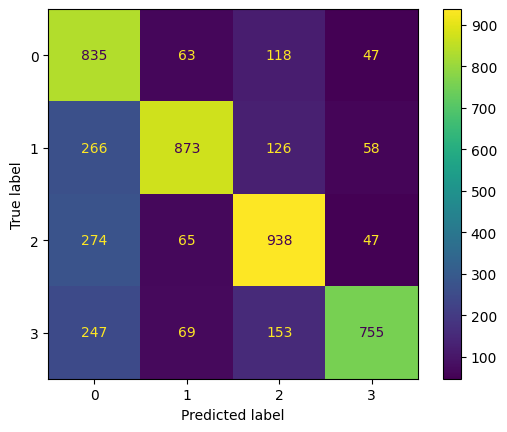

In [27]:
evaluate_results(results)

From this confusion matrix we can conclude that in all the cases the model gave a letter that matched one of the options. And most of the answers where correct.

In [28]:
print_classification_report(results)

              precision    recall  f1-score   support

           0       0.51      0.79      0.62      1063
           1       0.82      0.66      0.73      1323
           2       0.70      0.71      0.71      1324
           3       0.83      0.62      0.71      1224

    accuracy                           0.69      4934
   macro avg       0.72      0.69      0.69      4934
weighted avg       0.72      0.69      0.69      4934



This classification report tells us that the model had a 69% accuracy over the full set of questions. 

### Middle School Dataset

In [29]:
middle_test_dataset_gpt2 = build_prompts(dataset_dict, subset='middle', split='test')

In [30]:
results = middle_test_dataset_gpt2.map(generate_predictions, batched=True)

Map:   0%|          | 0/1436 [00:00<?, ? examples/s]

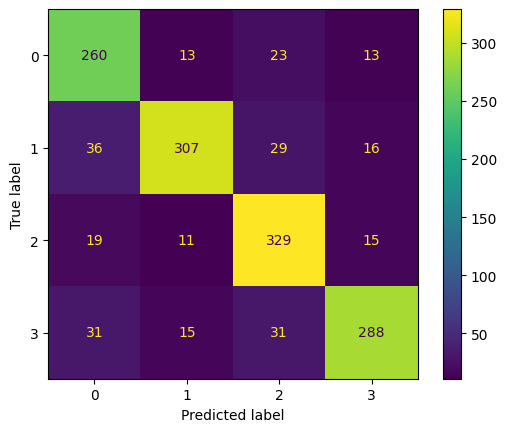

In [31]:
evaluate_results(results)

For this case no invalid tokens (outside of the option set) was generated and the questions were aswered with higher accuracy.

In [32]:
print_classification_report(results)

              precision    recall  f1-score   support

           0       0.75      0.84      0.79       309
           1       0.89      0.79      0.84       388
           2       0.80      0.88      0.84       374
           3       0.87      0.79      0.83       365

    accuracy                           0.82      1436
   macro avg       0.83      0.83      0.82      1436
weighted avg       0.83      0.82      0.82      1436



The accuracy value for the middle school questions was 82%. This helps to support the hypothesis that middle school questions are easier to solve than high school ones.

### High School Dataset

In [33]:
high_test_dataset_gpt2 = build_prompts(dataset_dict, subset='high', split='test')

In [34]:
results = high_test_dataset_gpt2.map(generate_predictions, batched=True)

Map:   0%|          | 0/3498 [00:00<?, ? examples/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


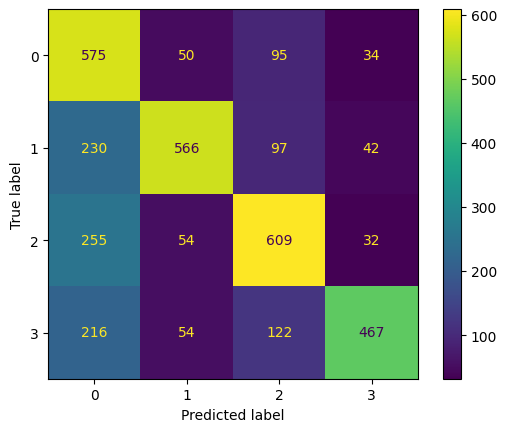

In [35]:
evaluate_results(results)

The set of misclassified answers for this case is higher, as shown by the confusion matrix, the most frequent answer was option "A". 

In [36]:
print_classification_report(results)

              precision    recall  f1-score   support

           0       0.45      0.76      0.57       754
           1       0.78      0.61      0.68       935
           2       0.66      0.64      0.65       950
           3       0.81      0.54      0.65       859

    accuracy                           0.63      3498
   macro avg       0.68      0.64      0.64      3498
weighted avg       0.68      0.63      0.64      3498



An accuracy of 63% over high school questions gives us further validation that high school questions are harder to answer.

## One-shot Prompting

One-shot learning means showing the model an example before giving the actual task to perform. For this, as explained before for the helper fucntions, a sample question related to the same passage is extracted and placed as an example, if possible. In case that no other question is available, a default question will be placed.

### Full Dataset

In [37]:
all_test_dataset_gpt2 = build_prompts(dataset_dict, split='test', prompt_type="one")

In [38]:
generate_answer(all_test_dataset_gpt2[48])

Prompt:

Given the following context and question with options, select the letter (A, B, C or D) that correspond to the correct answer:
<Context> A new law helps people with disabilities. The law says that people with disabilities must be able to get into and out of all public buildings. It also says that business must offer special services to people who have special needs. Companies can not refuse to hire disabled workers. Many businesses may have to change their buildings and services.
--Ramps must be built so people can get into buildings.
--Movie theatres must have space for people in wheelchairs and seats for their friends to sit near them.
--Elevators must have floor number in  _ .
This law will help millions of people. One woman who has been in a wheelchair for many years said, "It is like a dream."
<Question> The word "Braille" means_.

A) words known by foreigners
B) words known by common people
C) words on walls
D) words known by the blind
(Select: A, B, C, or D) <Answer>: D

In [39]:
results = all_test_dataset_gpt2.map(generate_predictions, batched=True)

Map:   0%|          | 0/4934 [00:00<?, ? examples/s]

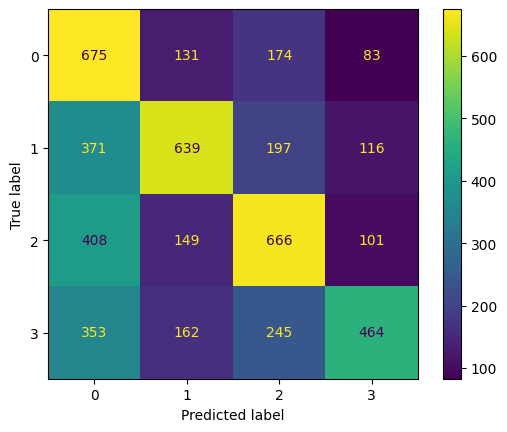

In [40]:
evaluate_results(results)

In [41]:
print_classification_report(results)

              precision    recall  f1-score   support

           0       0.37      0.63      0.47      1063
           1       0.59      0.48      0.53      1323
           2       0.52      0.50      0.51      1324
           3       0.61      0.38      0.47      1224

    accuracy                           0.50      4934
   macro avg       0.52      0.50      0.49      4934
weighted avg       0.53      0.50      0.50      4934



The overall accuracy has decreased significantly with the one-shot case. Comparing with the equivalent case in the zero-shot scenario, the model exhibits a bias towards option "A". This can happen as part of **possible noise introduced by the example question**, at least for the case of the default question whose asnwer is marked as "A". Hence, *the performances for the two subsets is expected to decay as well*.

### Middle School Dataset

In [42]:
middle_test_dataset_gpt2 = build_prompts(dataset_dict, subset='middle', split='test', prompt_type="one")

In [43]:
results = middle_test_dataset_gpt2.map(generate_predictions, batched=True)

Map:   0%|          | 0/1436 [00:00<?, ? examples/s]

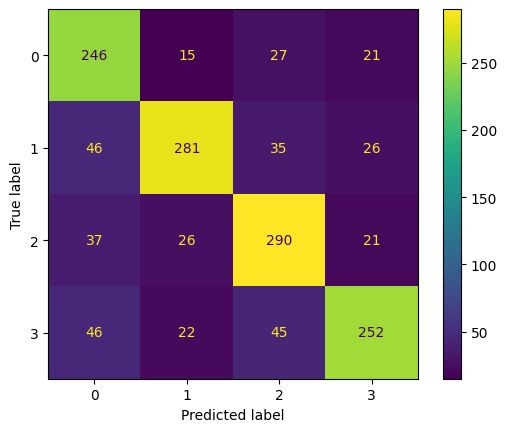

In [44]:
evaluate_results(results)

In [45]:
print_classification_report(results)

              precision    recall  f1-score   support

           0       0.66      0.80      0.72       309
           1       0.82      0.72      0.77       388
           2       0.73      0.78      0.75       374
           3       0.79      0.69      0.74       365

    accuracy                           0.74      1436
   macro avg       0.75      0.75      0.74      1436
weighted avg       0.75      0.74      0.75      1436



The accuracy of the model also decreased for this subset (from 82% to 74%). Nevertheless, the overall distribution of the answers doesn't show a high bias towards option "A" as for the case before.

### High School Dataset

In [46]:
high_test_dataset_gpt2 = build_prompts(dataset_dict, subset='high', split='test', prompt_type="one")

In [47]:
results = high_test_dataset_gpt2.map(generate_predictions, batched=True)

Map:   0%|          | 0/3498 [00:00<?, ? examples/s]

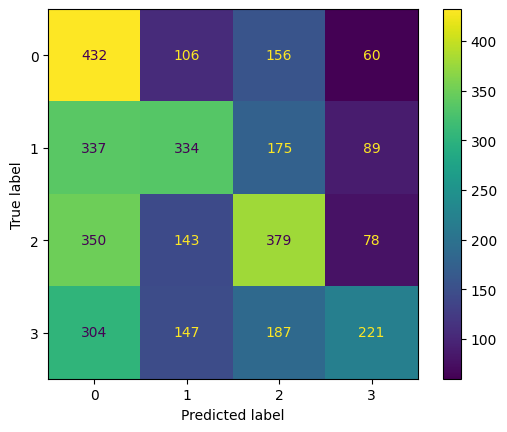

In [48]:
evaluate_results(results)

In [49]:
print_classification_report(results)

              precision    recall  f1-score   support

           0       0.30      0.57      0.40       754
           1       0.46      0.36      0.40       935
           2       0.42      0.40      0.41       950
           3       0.49      0.26      0.34       859

    accuracy                           0.39      3498
   macro avg       0.42      0.40      0.39      3498
weighted avg       0.42      0.39      0.39      3498



Finally, for the high school the accuracy decreased dratically going from 63% to 39%. in this case the bias towards the label "A" is much more visible. To further validate the efect of the examples on the model's accuracy the few-shot learning will be analyzed.

## Few-shot Prompting

### Full Dataset

In [24]:
all_test_dataset_gpt2 = build_prompts(dataset_dict, split='test', prompt_type="few")

In [25]:
generate_answer(all_test_dataset_gpt2[48])

Prompt:

Given the following context and question with options, select the letter (A, B, C or D) that correspond to the correct answer:
<Context> A new law helps people with disabilities. The law says that people with disabilities must be able to get into and out of all public buildings. It also says that business must offer special services to people who have special needs. Companies can not refuse to hire disabled workers. Many businesses may have to change their buildings and services.
--Ramps must be built so people can get into buildings.
--Movie theatres must have space for people in wheelchairs and seats for their friends to sit near them.
--Elevators must have floor number in  _ .
This law will help millions of people. One woman who has been in a wheelchair for many years said, "It is like a dream."
<Question> According to the passage we can see that_.

A) it will be difficult for the normal persons to get into the public buildings
B) the buildings of all the businesses will ha

In [26]:
results = all_test_dataset_gpt2.map(generate_predictions, batched=True)

Map:   0%|          | 0/4934 [00:00<?, ? examples/s]

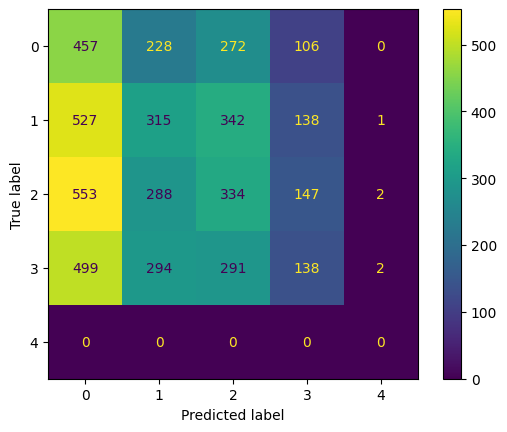

In [27]:
evaluate_results(results)

In [28]:
print_classification_report(results)

Other answer sample 1: Answer
Other answer sample 2: Answer
Other answer sample 3: Answer
Other answer sample 4: Answer
Other answer sample 5: Answer
              precision    recall  f1-score   support

           0       0.22      0.43      0.29      1063
           1       0.28      0.24      0.26      1323
           2       0.27      0.25      0.26      1324
           3       0.26      0.11      0.16      1224
           4       0.00      1.00      0.00         0

    accuracy                           0.25      4934
   macro avg       0.21      0.41      0.19      4934
weighted avg       0.26      0.25      0.24      4934



The accuracy decreased by half in comparison with the full dataset on the case of One-shot learning. In this case, it appears that **more noise has been introduced to the model** as it gave some options that weren't part of the original set (A, B, C or D.) but instead returned the token "Answer".

### Middle School Dataset

In [29]:
middle_test_dataset_gpt2 = build_prompts(dataset_dict, subset='middle', split='test', prompt_type="few")

In [30]:
results = middle_test_dataset_gpt2.map(generate_predictions, batched=True)

Map:   0%|          | 0/1436 [00:00<?, ? examples/s]

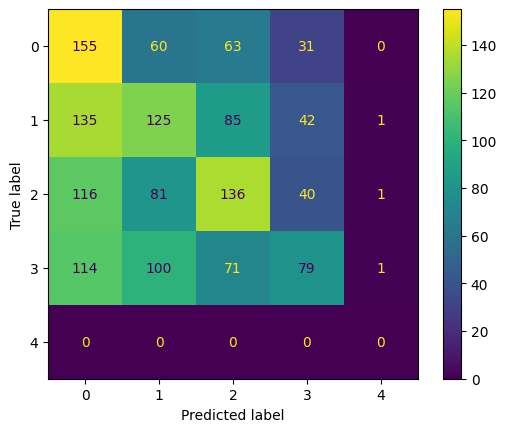

In [31]:
evaluate_results(results)

In [32]:
print_classification_report(results)

Other answer sample 1: Answer
Other answer sample 2: Answer
Other answer sample 3: Answer
              precision    recall  f1-score   support

           0       0.30      0.50      0.37       309
           1       0.34      0.32      0.33       388
           2       0.38      0.36      0.37       374
           3       0.41      0.22      0.28       365
           4       0.00      1.00      0.00         0

    accuracy                           0.34      1436
   macro avg       0.29      0.48      0.27      1436
weighted avg       0.36      0.34      0.34      1436



The model showed the same behaviour with the middle school question set, as it deacreases in its performance and gave 3 answers with the word "Answer".

### High School Dataset

In [33]:
high_test_dataset_gpt2 = build_prompts(dataset_dict, subset='high', split='test', prompt_type="few")

In [34]:
results = high_test_dataset_gpt2.map(generate_predictions, batched=True)

Map:   0%|          | 0/3498 [00:00<?, ? examples/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


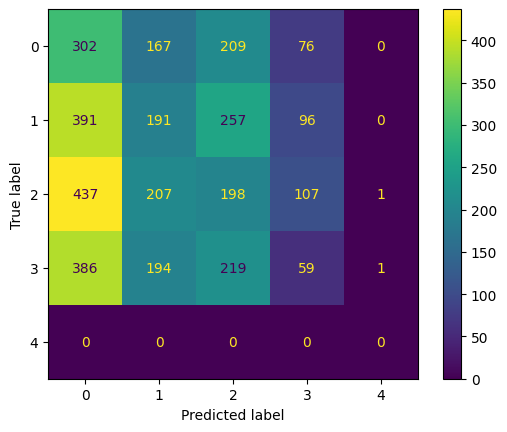

In [35]:
evaluate_results(results)

In [36]:
print_classification_report(results)

Other answer sample 1: Answer
Other answer sample 2: Answer
              precision    recall  f1-score   support

           0       0.20      0.40      0.27       754
           1       0.25      0.20      0.23       935
           2       0.22      0.21      0.22       950
           3       0.17      0.07      0.10       859
           4       0.00      1.00      0.00         0

    accuracy                           0.21      3498
   macro avg       0.17      0.38      0.16      3498
weighted avg       0.21      0.21      0.20      3498



Finally, in the high school dataset the performance decreased as well, with a much more higher bias towards the option "A".

## General Conclusions

In general, the FLAN model gave a solid performance without any fine tuning in the Zero-shot scenario. As expected, it performed better on the middle school questions. As more examples were included, the accuracy decreased.

To underestand this behaviour we have to take a deeper look into the FLAN T5 Model. This model is a fine-tuned verion of the multimodal T5 transformer model, as mentioned in the Hugging Face documentation for this model (https://huggingface.co/docs/transformers/model_doc/t5#transformers.T5Model) the maximum lenght for the relative atention is 128 tokens. This can explain the significant decay of the accuracy on the few-shot case: the examples gave the model a much more longer sequence to process and **some parts of the text may have been left out the attention reach**. Additionally, being an Encoder-Decoder model, the examples plus the limitation of only returning letters may have biased the model into taking the examples' answer letter.

# GPT-2 (Fine-tuning)

## Libraries Required

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer, pipeline, TrainingArguments, DataCollatorForLanguageModeling, Trainer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import os
from datasets import load_dataset, Dataset, DatasetDict
import numpy as np
import random

In [ ]:
set_seed(42)

## Introduction to the Experiment

To fine-tune a GPT-2 model, the input data will consist of sequences of questions containing:

- Context: Passage of the article relevant to answer the question.
- Question: Actual question related to the passage.
- Options: Labelled with letters (A, B, C or D) correspond to options of aswers to the given question.
- Answer: Letter corresponding to the correct answer.

Additionally, the special token `<|ans|>` is going to be added to help the model underestand the task. The final sequence will look like:

`<|bos|> Context: {context} Question: {question} {options} Answer (Select: A, B, C, or D): <|ans|> {answer_letter}<|eos|>`

In [132]:
device='cuda' if torch.cuda.is_available() else 'cpu'

model_name = "gpt2"
model = GPT2LMHeadModel.from_pretrained(model_name)
tokenizer = GPT2Tokenizer.from_pretrained(model_name)

In [133]:
tokenizer.pad_token = tokenizer.eos_token

ans_token = "<|ans|>"
tokenizer.add_special_tokens({"additional_special_tokens" : [ans_token]})
model.resize_token_embeddings(len(tokenizer))  

Embedding(50258, 768)

As found in the *section before*, long sequences aren't desirable. Hence, Sentence Semantic Similarity techniques will be used to reduce the context to just a small passage that's relevant to the question. For this, a Cross Encoder will be used. This type of models simultaneously encodes two sentences to generate a single embbeding (or score) that captures both of their representations and relationships. 

In this case, a full Sentence Transformer is not needed (as used in the lab session of the course) given that the context for each question is (and it need to be) given. The Cross Encoder will help to extract the specific paragraph or passage of that context that is related to the question and will help to get the correct answer.

In [20]:
xenc_model = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

The Cross Encoder will be used in the following helper function to extract the most relevant passage related to a given question.

In [23]:
def generate_passage_from_question(
    question,
    context_passages,
    re_ranking_model=xenc_model
):

    xenc_inputs = [(question, passage) for passage in context_passages]
    cross_scores = re_ranking_model.predict(xenc_inputs)
    passage_idx = np.argsort(-cross_scores)[0]
    passage = context_passages[passage_idx]

    return passage

Additionally, this set of helper functions will be used to prepare the dataset for the GPT-2 training:

`prepare_gpt2_datset`: It takes the dataset and constructs a new one extracting the requested split ('train', 'test', 'val') and subset ('all', 'middle', 'high'). 

It return a single Dataset object with the following structure:

```
{
  "promt" : <promts containing the context, question, options and the request for the answer>,
  "answer" : <letter corresponding to the correct answer>
}
```

`format_question`: It receives a question dict and return a string with the question for the prompt, optionally including the answer.

In [130]:
def format_question(q):
    question = q['question']
    options = q['options']

    options_block = "\n".join([f"{chr(65+i)}) {opt}" for i, opt in enumerate(options)])

    return f"Question: {question}\n\n{options_block}\nAnswer (Select: A, B, C, or D): \n"

def prepare_gpt2_datset(dataset_dict, subset='all', split='train'):
    data = dataset_dict[subset][split]

    prompts = []
    answers = []

    for article_id, article_entry in data.items():
        context_passages = article_entry['article_text'].split("\n")
        for q in article_entry['questions']:
            instruction_header = "Given the following context and question with options, select the letter (A, B, C or D) that correspond to the correct answer:"
            
            context = generate_passage_from_question(f"{q["question"]}\n{"\n".join(q['options'])}", context_passages)
            context_block = f"<Context> {context}"
            
            tail_block = format_question(q)
            prompt = f"{instruction_header}\n{context_block}\n{tail_block}"
            prompts.append(prompt)
            answers.append(q["answer"])
            

    processed_data = Dataset.from_dict({
        "prompt": prompts,
        "answer": answers
    })

    return processed_data

Additionally, as before, this set of functions will be used for generating the answers. Note that the parameter `return_full_text` need to used this time to avoid receiving the input text again. 

In [136]:
def generate_predictions(batch):
    generated_answers = generator(batch['prompt'], max_new_tokens=2, truncation=True, num_return_sequences=1, return_full_text=False)

    predicted_answers = [ans[0]['generated_text'] for ans in generated_answers]
    return {"predicted_answer": predicted_answers}
    
def generate_answer(sample):
    promt = sample["prompt"]
    expected_answer = sample["answer"]

    generated_answer = generator(promt, max_new_tokens=2, truncation=True, num_return_sequences=1, return_full_text=False)

    print("Prompt:\n")
    print(promt)
    print("\nGenerated Answer:\n")
    print(generated_answer[0]['generated_text'])
    print("\nExpected Answer:\n")
    print(expected_answer)

This set of evaluation functions are the same as the ones used for the FLAN model.

In [141]:
def evaluate_results(results):
    label_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'Other' : 4}

    true_labels_numeric = [label_map[label] for label in results['answer']]
    predicted_labels_numeric = [label_map[label.strip() if label.strip() in ['A', 'B', 'C', 'D'] else "Other"] for label in results['predicted_answer']]

    cm = confusion_matrix(true_labels_numeric, predicted_labels_numeric)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

def print_classification_report(results, num_others=5):

    label_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3}

    true_labels_numeric = [label_map[label] for label in results['answer']]

    predicted_labels_numeric = []
    other_answers_printed = 1

    for label in results['predicted_answer']:
        label = label.strip()
        if label in ['A', 'B', 'C', 'D']:
            predicted_labels_numeric.append(label_map[label])
        else:
            if other_answers_printed <= num_others:
                print(f"Other answer sample {other_answers_printed}: {label}")
                other_answers_printed+=1
            predicted_labels_numeric.append(4)

    report = classification_report(true_labels_numeric, predicted_labels_numeric, zero_division=1)
    print(report)

First, the dataset will be prepared for the training. The sequences are going to be generated including the use of the Cross Encoder to obtain a shorter sequence. To optimize further executions the result is going to be saved.

In [24]:
dataset_path = "./dataset_gpt2"

try:
    print("Trying to load the dataset from disk...")
    dataset_gpt2 = DatasetDict.load_from_disk(dataset_path)
    print("Dataset loaded from disk successfully.")
    
except Exception as e:
    print(f"Failed to load dataset from disk. Error: {e}")
    print("Computing the dataset...")

    dataset_gpt2 = DatasetDict()

    print("Processing train set...")
    dataset_gpt2['train'] = prepare_gpt2_datset(dataset_dict, split='train')
    print("Processing test set...")
    dataset_gpt2['test'] = prepare_gpt2_datset(dataset_dict, split='test')
    print("Processing validation set...")
    dataset_gpt2['validation'] = prepare_gpt2_datset(dataset_dict, split='validation')

    print(f"Saving the computed dataset to disk at {dataset_path}...")
    dataset_gpt2.save_to_disk(dataset_path)
    print("Dataset saved to disk successfully.")

Trying to load the dataset from disk...
Dataset loaded from disk successfully.


Here is an example of a data sample:

In [25]:
print(dataset_gpt2['train'][0])

{'prompt': 'Given the following context and question with options, select the letter (A, B, C or D) that correspond to the correct answer:\n<Context> Given that I teach students who are training to be doctors, I was surprised do find that most thought that they would not be able to get the jobs they wanted without "outside help". "What kind of help is that?" I asked, expecting them to tell me that they would need a   or family friend to help them out.\nQuestion: We can know from the passage that the author works as a_.\n\nA) doctor\nB) model\nC) teacher\nD) reporter\nAnswer (Select: A, B, C, or D): \n', 'answer': 'C'}


## Baseline Execution

To compare the efect of the fine-tuning, first we are going to check the performance of the GPT-2 model without any further training.

In [137]:
generator = pipeline("text-generation", model=model, tokenizer=tokenizer)

Device set to use cuda:0


In [138]:
results = dataset_gpt2["test"].map(generate_predictions, batched=True)

Map:   0%|          | 0/4934 [00:00<?, ? examples/s]

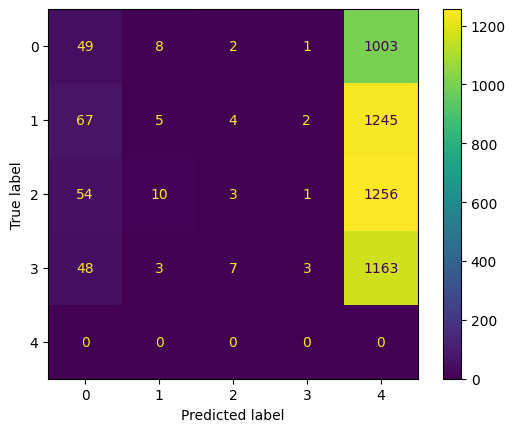

In [142]:
evaluate_results(results)

In [143]:
print_classification_report(results)

Other answer sample 1: <Context
Other answer sample 2: When I
Other answer sample 3: We
Other answer sample 4: A)
Other answer sample 5: "
              precision    recall  f1-score   support

           0       0.22      0.05      0.08      1063
           1       0.19      0.00      0.01      1323
           2       0.19      0.00      0.00      1324
           3       0.43      0.00      0.00      1224
           4       0.00      1.00      0.00         0

    accuracy                           0.01      4934
   macro avg       0.21      0.21      0.02      4934
weighted avg       0.26      0.01      0.02      4934



The model performed poorly on the dataset, giving **mostly unrelated tokens that didn't correspond to any answer.**

## Model Fine-tuning

With the baseline execution done, the fine-tuning process can be now be performed. First all the data need to be tokenized in order to be passed to the model. For the tokenization, the special token `<|ans|>` will be added between the question statement and the answer letter.

In [47]:
def tokenize_function(examples):
    prompts = examples["prompt"]
    answers = examples["answer"]

    inputs = [f"{prompt}{ans_token}{answer}" for prompt, answer in zip(prompts, answers)]

    input_encodings = tokenizer(inputs, padding=True, truncation=True, max_length=256)

    return {
        'input_ids': input_encodings['input_ids']
    }

tokenized_data = dataset_gpt2.map(tokenize_function, batched=True, remove_columns=dataset_gpt2['train'].column_names)

Map:   0%|          | 0/87866 [00:00<?, ? examples/s]

Map:   0%|          | 0/4934 [00:00<?, ? examples/s]

Map:   0%|          | 0/4887 [00:00<?, ? examples/s]

**Important Note:** to further reduce the training time a subset of the training set will be processed. (Training with the full dataset, even at small batch sized was giving an stimate of >100 hours)

In [53]:
train_size = len(tokenized_data['train'])
sample_size = int(train_size * 0.1)

sample_indices = random.sample(range(train_size), sample_size)

train_subset = tokenized_data['train'].select(sample_indices)

In the following cells the hyperparameters for the fine-tuning are set, among the most important ones we have:

- `per_device_train_batch_size`: Set to 2 to help reduce training time.
- `bf16`: Enables floating point mixed precision to help reduce memory usage and training time.

In [54]:
training_args = TrainingArguments(
    "gpt-2_model",
    per_device_train_batch_size=2,
    learning_rate=3e-5,
    bf16=True,
    report_to=None,
    eval_strategy="no"
)

Additionally, a Data Collator is used to build the data batches. The option for mlm (Mask for Language Modeling) is disabled as it is not the objective of this training.

In [ ]:
data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

Finally, the Trainer object is created:

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_subset,
    eval_dataset=tokenized_data['validation'],
    data_collator=data_collator
)

In [55]:
trainer.train()

Step,Training Loss
500,1.978700
1000,1.986300
1500,2.091300
2000,2.221500
2500,2.171700
3000,2.188400
3500,2.192000
4000,2.159100
4500,2.113600
5000,1.990600


TrainOutput(global_step=13179, training_loss=1.9958300099530977, metrics={'train_runtime': 8397.9767, 'train_samples_per_second': 3.139, 'train_steps_per_second': 1.569, 'total_flos': 3443567689728000.0, 'train_loss': 1.9958300099530977, 'epoch': 3.0})

Given the considerably long (2h) training time, the model will be saved for further operations.

In [57]:
model_dir = "./race_gpt-2_model"
trainer.save_model(model_dir)
tokenizer.save_pretrained(model_dir)

('./race_gpt-2_model/tokenizer_config.json',
 './race_gpt-2_model/special_tokens_map.json',
 './race_gpt-2_model/vocab.json',
 './race_gpt-2_model/merges.txt',
 './race_gpt-2_model/added_tokens.json')

In [58]:
trainer.evaluate()

{'eval_loss': 2.0415027141571045,
 'eval_runtime': 629.4178,
 'eval_samples_per_second': 7.764,
 'eval_steps_per_second': 0.971,
 'epoch': 3.0}

## Fine-tuned Model Evaluation

Now, the saved model will be tested to be compared with the baseline execution.

In [61]:
model = GPT2LMHeadModel.from_pretrained(model_dir)
tokenizer = GPT2Tokenizer.from_pretrained(model_dir)
generator = pipeline("text-generation", model=model, tokenizer=tokenizer)

In [79]:
results = dataset_gpt2["test"].map(generate_predictions, batched=True)

Map:   0%|          | 0/4934 [00:00<?, ? examples/s]

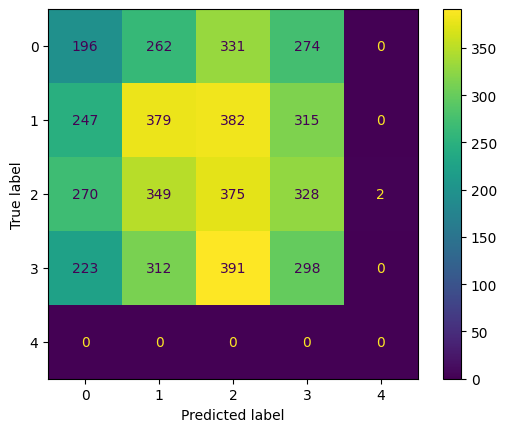

In [80]:
evaluate_results(results)

In [81]:
print_classification_report(results)

Other answer sample 1: N
Other answer sample 2: E
              precision    recall  f1-score   support

           0       0.21      0.18      0.20      1063
           1       0.29      0.29      0.29      1323
           2       0.25      0.28      0.27      1324
           3       0.25      0.24      0.24      1224
           4       0.00      1.00      0.00         0

    accuracy                           0.25      4934
   macro avg       0.20      0.40      0.20      4934
weighted avg       0.25      0.25      0.25      4934



Despite being trained on a subsample of the training data, the model exhibited a significant increase on its accuracy going from nearly a 0% to a 25%. Moreover, the great majority of the generated answers corresponded to actual options of the questions with just 2 samples being incorrect ("N" and "E").